# Import Library & Data

In [1]:
!pip install nptdms

In [2]:
import os
import numpy as np
import pandas as pd
from nptdms import TdmsFile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_DIR = '/content/drive/MyDrive/projektsc/datap/1.0kW/vibration'
WINDOW_SIZE = 2048 # Ukuran pemotongan sinyal (segmen time-series)

EXPORT_DIR = '/content/drive/MyDrive/projektsc/hasil/'


In [5]:
X_data = []
y_labels = []

In [6]:
# Ekstraksi TDMS dan Segmentasi Sinyal
for file_name in os.listdir(DATA_DIR):
    if file_name.endswith('.tdms'):
        file_path = os.path.join(DATA_DIR, file_name)

        # Penarikan label dari nama file berdasarkan format Mendeley (aaaaW_bb_cc_vibration_dddd.tdms)
        if '0_00' in file_name:
            label = 'normal'
        elif 'coil' in file_name.lower():
            label = 'coil_short'
        elif 'interturn' in file_name.lower():
            label = 'interturn_short'
        else:
            continue

        # Membaca TDMS
        tdms_file = TdmsFile.read(file_path)

        # Iterasi untuk mencari grup yang memiliki channel data
        vibration_signal = None
        for group in tdms_file.groups():
            channels = group.channels()
            if len(channels) > 0:
                vibration_signal = channels[0].data
                break

        # Validasi jika file benar-benar kosong atau rusak
        if vibration_signal is None or len(vibration_signal) < WINDOW_SIZE:
            print(f"Melewati {file_name}: Tidak ada channel data atau sinyal terlalu pendek.")
            continue

        # Windowing (Memotong sinyal panjang menjadi potongan-potongan kecil)
        num_windows = len(vibration_signal) // WINDOW_SIZE
        for i in range(num_windows):
            start_idx = i * WINDOW_SIZE
            end_idx = start_idx + WINDOW_SIZE
            segment = vibration_signal[start_idx:end_idx]

            X_data.append(segment)
            y_labels.append(label)

# Konversi ke format Numpy Array
X = np.array(X_data)
y = np.array(y_labels)

# Pre-processing

In [7]:
# Label Encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [8]:
#Rekayasa Dimensi Input Model (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

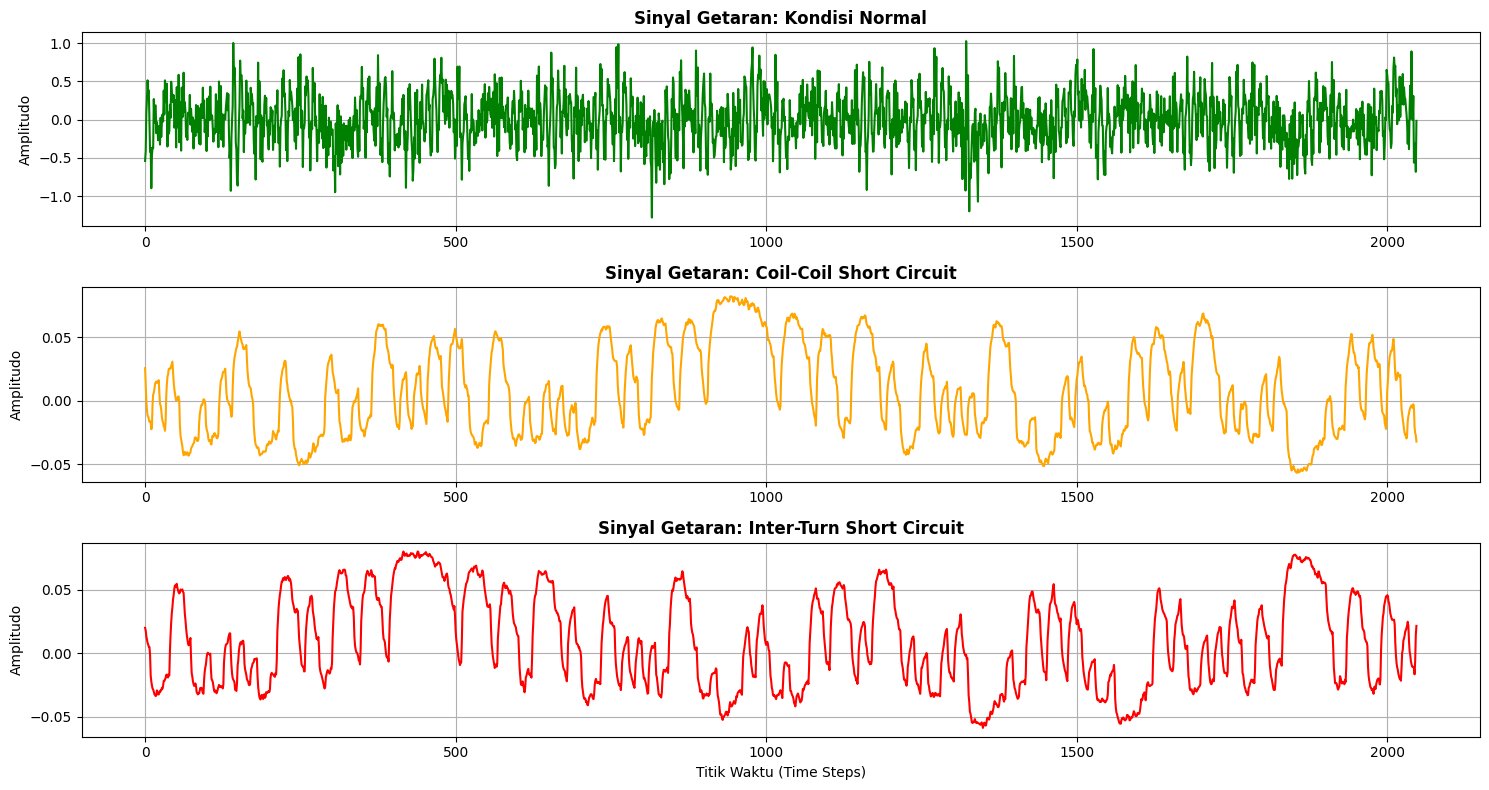

In [9]:
# visualisasi preprocessing

# indeks pertama untuk tiapkelas
idx_normal = np.where(y == 'normal')[0][0]
idx_coil = np.where(y == 'coil_short')[0][0]
idx_interturn = np.where(y == 'interturn_short')[0][0]
plt.figure(figsize=(15, 8))

# Plot Sinyal Normal
plt.subplot(3, 1, 1)
plt.plot(X[idx_normal], color='green')
plt.title('Sinyal Getaran: Kondisi Normal', fontsize=12, fontweight='bold')
plt.ylabel('Amplitudo')
plt.grid(True)

# Sinyal Coil Short
plt.subplot(3, 1, 2)
plt.plot(X[idx_coil], color='orange')
plt.title('Sinyal Getaran: Coil-Coil Short Circuit', fontsize=12, fontweight='bold')
plt.ylabel('Amplitudo')
plt.grid(True)

# Sinyal Inter-turn Short
plt.subplot(3, 1, 3)
plt.plot(X[idx_interturn], color='red')
plt.title('Sinyal Getaran: Inter-Turn Short Circuit', fontsize=12, fontweight='bold')
plt.xlabel('Titik Waktu (Time Steps)')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

Distribusi Sampel Data Latih:
- Kelas coil_short: 7761 sampel matriks
- Kelas interturn_short: 7763 sampel matriks
- Kelas normal: 3000 sampel matriks


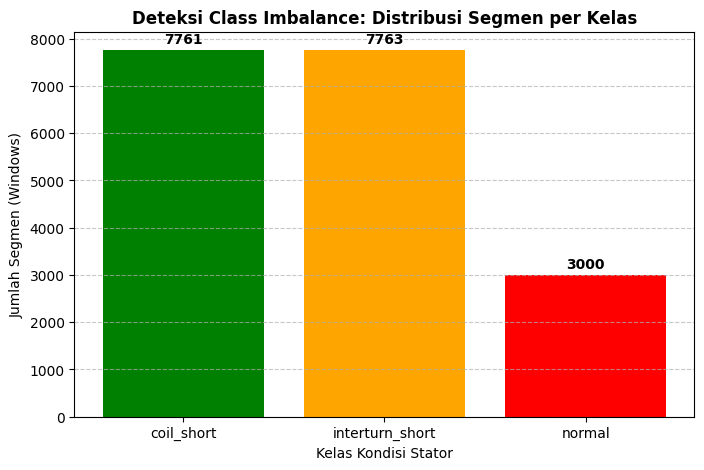

In [10]:
# Komputasi class distribution pada matriks label
unique_classes, counts = np.unique(y, return_counts=True)
print("Distribusi Sampel Data Latih:")
for cls, count in zip(unique_classes, counts):
    print(f"- Kelas {cls}: {count} sampel matriks")

# Grafik batang untuk visualisasi distribusi
plt.figure(figsize=(8, 5))
bars = plt.bar(unique_classes, counts, color=['green', 'orange', 'red'])
plt.title('Deteksi Class Imbalance: Distribusi Segmen per Kelas', fontweight='bold')
plt.xlabel('Kelas Kondisi Stator')
plt.ylabel('Jumlah Segmen (Windows)')
plt.grid(axis='y', linestyle='--', alpha=0.7)


# Penambaahan label angka di atas setiap batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.01),
             int(yval), ha='center', va='bottom', fontweight='bold')
plt.show()

In [11]:
# data spliting(80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Modelling

In [12]:
# 1d-cnn architekture
model = Sequential([
    Conv1D(filters=64, kernel_size=32, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    MaxPooling1D(pool_size=4),
    Conv1D(filters=32, kernel_size=16, activation='relu'),
    MaxPooling1D(pool_size=4),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2017, 64)       │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 504, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 489, 32)        │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 122, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3904)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       499,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,139 (2.04 MB)

 Trainable params: 535,139 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

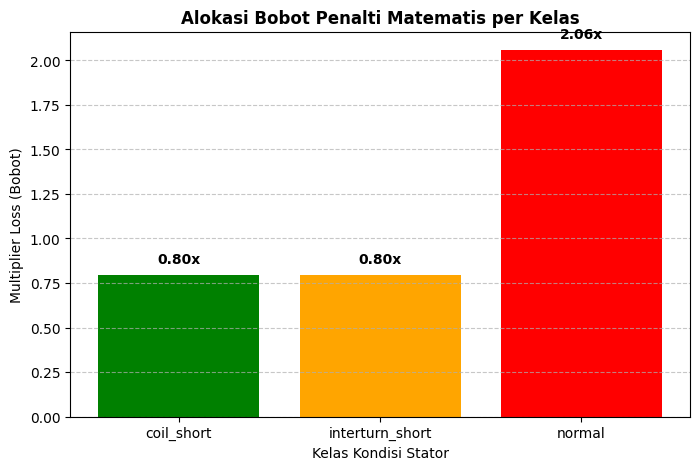

In [13]:
# Pembobotan
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weights_dict = {i: weight for i, weight in enumerate(weights)}

# 2. Visualisasi Besaran Bobot (Multiplier)
plt.figure(figsize=(8, 5))
bars = plt.bar(encoder.classes_, weights, color=['green', 'orange', 'red'])
plt.title('Alokasi Bobot Penalti Matematis per Kelas', fontweight='bold')
plt.xlabel('Kelas Kondisi Stator')
plt.ylabel('Multiplier Loss (Bobot)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05,
             f"{yval:.2f}x", ha='center', va='bottom', fontweight='bold')

plt.show()

In [14]:
# training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nMemulai pelatihan model...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)



Memulai pelatihan model...
Epoch 1/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 129s 503ms/step - accuracy: 0.7192 - loss: 0.3422 - val_accuracy: 0.7409 - val_loss: 0.3590
Epoch 2/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 106s 457ms/step - accuracy: 0.7432 - loss: 0.2858 - val_accuracy: 0.7414 - val_loss: 0.3589
Epoch 3/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 141s 453ms/step - accuracy: 0.7426 - loss: 0.2849 - val_accuracy: 0.7358 - val_loss: 0.3589
Epoch 4/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 141s 449ms/step - accuracy: 0.7422 - loss: 0.2842 - val_accuracy: 0.7425 - val_loss: 0.3598
Epoch 5/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 106s 459ms/step - accuracy: 0.7468 - loss: 0.2842 - val_accuracy: 0.7401 - val_loss: 0.3587
Epoch 6/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 104s 450ms/step - accuracy: 0.7432 - loss: 0.2840 - val_accuracy: 0.7401 - val_loss: 0.3588
Epoch 7/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 142s 452ms/step - accuracy: 0.7432 - loss: 0.2838 - val_accuracy: 0.7401 - val_loss: 0.3595
Epoch 8/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 141s 448

# Evaluations


In [15]:
# Akurasi (x > 70%)
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi Pengujian: {accuracy * 100:.2f}%")

116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7401 - loss: 0.3587
Akurasi Pengujian: 74.01%


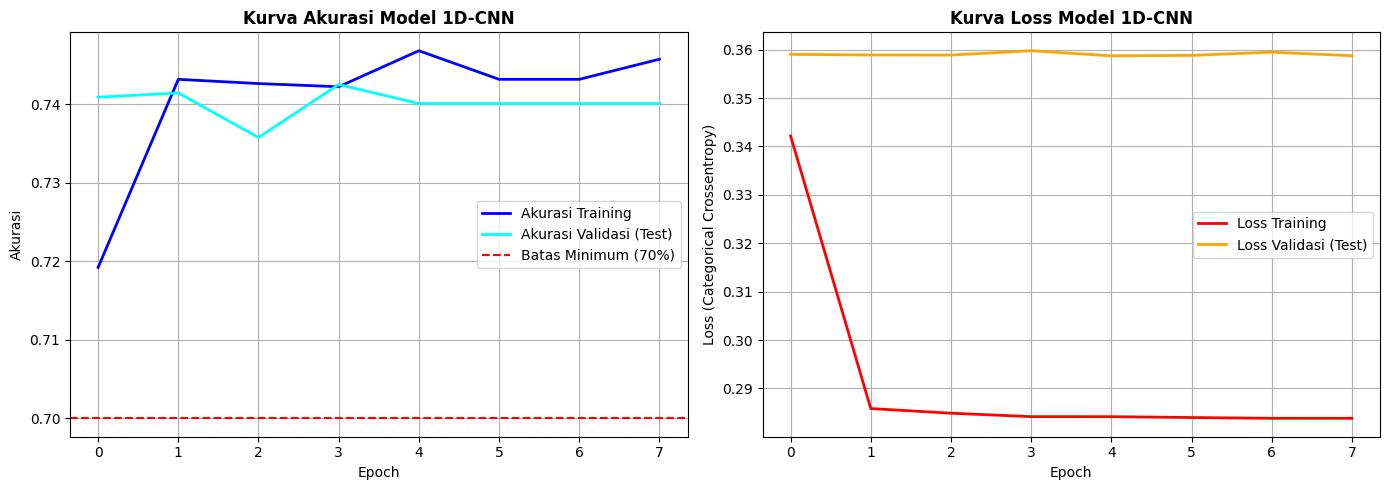

In [16]:
# Grafik Akurasi
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi (Test)', color='cyan', linewidth=2)
plt.axhline(y=0.70, color='red', linestyle='--', label='Batas Minimum (70%)')
plt.title('Kurva Akurasi Model 1D-CNN', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Loss Validasi (Test)', color='orange', linewidth=2)
plt.title('Kurva Loss Model 1D-CNN', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


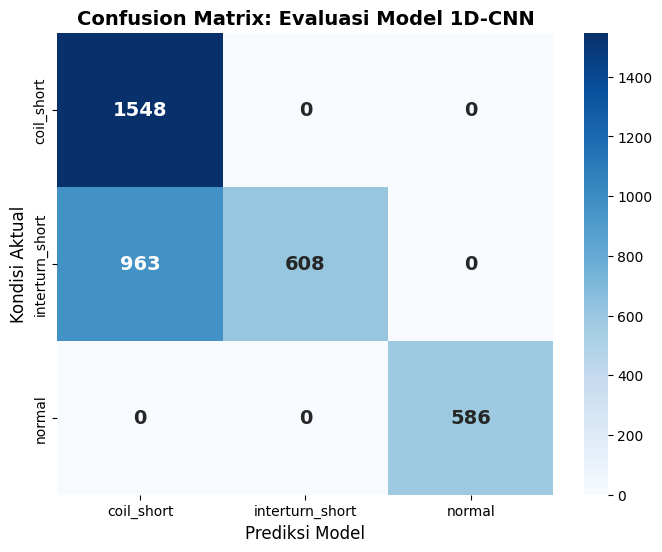

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Eksekusi Prediksi pada Data Uji
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Komputasi Matriks Konfusi
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix: Evaluasi Model 1D-CNN', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Kondisi Aktual', fontsize=12)
plt.show()

# Exporting model (.h5 & .npy)

In [18]:
model.save(EXPORT_DIR + 'pmsm_vibration_model.h5')
np.save(EXPORT_DIR + 'label_classes.npy', encoder.classes_)